# Healthcare Revenue Optimization & Claim Denial Analytics

## Project Overview

This project analyzes a synthetic California hospital dataset (Q1 2025) using Python. The objective is to explore hospital revenue cycle performance, identify claim denial patterns, analyze insurance provider performance, and generate business insights that support better financial decision-making.

**Tools Used:**
- Python
- Pandas
- NumPy
- Matplotlib

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load Dataset

In [2]:
patients = pd.read_csv("../data/patients.csv")
providers = pd.read_csv("../data/providers.csv")
encounters = pd.read_csv("../data/encounters.csv")
diagnoses = pd.read_csv("../data/diagnoses.csv")
procedures = pd.read_csv("../data/procedures.csv")
medications = pd.read_csv("../data/medications.csv")
lab_tests = pd.read_csv("../data/lab_tests.csv")
claims = pd.read_csv("../data/claims_and_billing.csv")
denials = pd.read_csv("../data/denials.csv")

## Dataset Overview

In [3]:
datasets = {
    "Patients": patients,
    "Providers": providers,
    "Encounters": encounters,
    "Diagnoses": diagnoses,
    "Procedures": procedures,
    "Medications": medications,
    "Lab Tests": lab_tests,
    "Claims": claims,
    "Denials": denials
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

Patients: (60000, 16)
Providers: (1491, 10)
Encounters: (70000, 13)
Diagnoses: (70000, 6)
Procedures: (126021, 7)
Medications: (94498, 10)
Lab Tests: (54537, 10)
Claims: (70000, 11)
Denials: (5998, 10)


In [4]:
claims.head()

,billing_id,patient_id,encounter_id,insurance_provider,payment_method,claim_id,claim_billing_date,billed_amount,paid_amount,claim_status,denial_reason
0,BILL000001,PAT001464,ENC000001,BCBS,Insurance,CLM000001,06-02-2025 00:00,1971.52,0.00,Denied,Claim Billed to Wrong Payer
1,BILL000002,PAT025832,ENC000002,Medicare,Insurance,CLM000002,01-05-2025 00:00,1243.80,736.05,Paid,NaN
2,BILL000003,PAT055873,ENC000003,BCBS,Insurance,CLM000003,23-02-2025 00:00,4854.11,2676.12,Paid,NaN
3,BILL000004,PAT048558,ENC000004,BCBS,Insurance,CLM000004,20-04-2025 00:00,2638.21,1861.39,Paid,NaN
4,BILL000005,PAT018366,ENC000005,BCBS,Selfpay,NaN,NaN,1046.99,1046.99,Paid,NaN


In [5]:
claims.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   billing_id          70000 non-null  str    
 1   patient_id          70000 non-null  str    
 2   encounter_id        70000 non-null  str    
 3   insurance_provider  70000 non-null  str    
 4   payment_method      70000 non-null  str    
 5   claim_id            59638 non-null  str    
 6   claim_billing_date  59638 non-null  str    
 7   billed_amount       70000 non-null  float64
 8   paid_amount         70000 non-null  float64
 9   claim_status        70000 non-null  str    
 10  denial_reason       5998 non-null   str    
dtypes: float64(2), str(9)
memory usage: 5.9 MB


In [6]:
claims.describe()

,billed_amount,paid_amount
count,70000.000000,70000.000000
mean,1612.866283,1040.652151
std,2047.355083,1478.713641
min,100.070000,0.000000
25%,697.047500,366.572500
50%,1214.110000,755.785000
75%,2090.125000,1357.895000
max,38191.350000,38191.350000


## Data Cleaning & Validation

In [7]:
claims.isnull().sum()

billing_id                0
patient_id                0
encounter_id              0
insurance_provider        0
payment_method            0
claim_id              10362
claim_billing_date    10362
billed_amount             0
paid_amount               0
claim_status              0
denial_reason         64002
dtype: int64

In [8]:
claims.duplicated().sum()

np.int64(0)

In [9]:
providers.columns.tolist()

['provider_id',
 'name',
 'department',
 'specialty',
 'npi',
 'inhouse',
 'location',
 'years_experience',
 'contact_info',
 'email']

In [10]:
encounters.columns.tolist()

['encounter_id',
 'patient_id',
 'provider_id',
 'visit_date',
 'visit_type',
 'department',
 'reason_for_visit',
 'diagnosis_code',
 'admission_type',
 'discharge_date',
 'length_of_stay',
 'status',
 'readmitted_flag']

In [11]:
denials.columns.tolist()

['claim_id',
 'denial_id',
 'denial_reason_code',
 'denial_reason_description',
 'denied_amount',
 'denial_date',
 'appeal_filed',
 'appeal_status',
 'appeal_resolution_date',
 'final_outcome']

In [12]:
claims["claim_billing_date"].head(10)

0    06-02-2025 00:00
1    01-05-2025 00:00
2    23-02-2025 00:00
3    20-04-2025 00:00
4                 NaN
5    06-02-2025 00:00
6    26-02-2025 00:00
7    12-02-2025 00:00
8    14-03-2025 00:00
9    08-03-2025 00:00
Name: claim_billing_date, dtype: str

In [13]:
# Convert claim billing date to datetime

claims["claim_billing_date"] = pd.to_datetime(
    claims["claim_billing_date"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

claims["claim_billing_date"].dtype

dtype('<M8[us]')

## Feature Engineering

In [14]:
claims["revenue_leakage"] = claims["billed_amount"] - claims["paid_amount"]

In [15]:
claims[["billed_amount","paid_amount","revenue_leakage"]].head()

,billed_amount,paid_amount,revenue_leakage
0,1971.52,0.00,1971.52
1,1243.80,736.05,507.75
2,4854.11,2676.12,2177.99
3,2638.21,1861.39,776.82
4,1046.99,1046.99,0.00


## KPI Summary

In [16]:
print("Total Revenue Billed :", round(claims["billed_amount"].sum(),2))
print("Total Revenue Collected :", round(claims["paid_amount"].sum(),2))
print("Revenue Leakage :", round(claims["revenue_leakage"].sum(),2))

Total Revenue Billed : 112900639.84
Total Revenue Collected : 72845650.54
Revenue Leakage : 40054989.3


In [17]:
collection_rate = (
    claims["paid_amount"].sum() /
    claims["billed_amount"].sum()
) * 100

print("Collection Rate:", round(collection_rate,2),"%")

Collection Rate: 64.52 %


## Claim Status Analysis

In [18]:
claims["claim_status"].value_counts()

claim_status
Paid      64002
Denied     5998
Name: count, dtype: int64

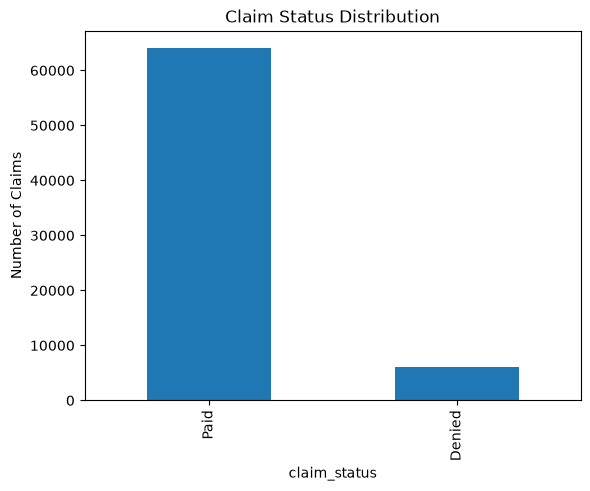

In [19]:
claims["claim_status"].value_counts().plot(kind="bar")
plt.title("Claim Status Distribution")
plt.ylabel("Number of Claims")
plt.show()

#### Observation

- Most insurance claims were successfully approved.
- Denied or pending claims represented a smaller portion of the total claims.

## Claim Denial Analysis

In [20]:
top_denials = denials["denial_reason_description"].value_counts()
top_denials

denial_reason_description
Duplicate claim/service.                                                   472
Precertification/authorization/notification absent.                        457
Non-covered charges                                                        437
Claim denied because it was filed after the timely filing deadline.        437
This care may be covered by another payer per coordination of benefits.    436
Submission/billing error patient has no coverage with this plan.           435
Benefit maximum for this time period or occurrence has been reached.       432
Claim not covered by this payer/contractor.                                425
Claim billed to wrong payer.                                               422
Treatment was rendered in an invalid or inappropriate place of service.    416
Claim/service lacks information or has submission/billing error.           414
Coverage terminated prior to DOS or patient not eligible.                  412
Diagnosis inconsistent wit

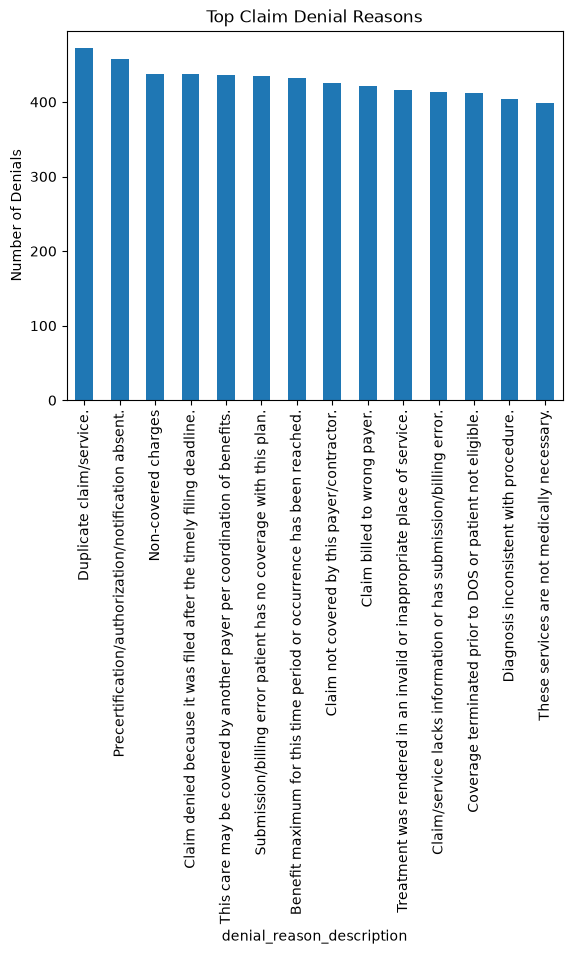

In [21]:
top_denials.plot(kind="bar")
plt.title("Top Claim Denial Reasons")
plt.ylabel("Number of Denials")
plt.show()

#### Observation

- duplicate claim services were among the most common reasons for claim denials.
- Reducing these denials could improve the overall collection rate.

In [22]:
revenue_loss = denials.groupby("denial_reason_description")["denied_amount"].sum().sort_values(ascending=False)
revenue_loss

denial_reason_description
Precertification/authorization/notification absent.                        766140.06
Claim billed to wrong payer.                                               736240.89
Submission/billing error patient has no coverage with this plan.           732639.24
Benefit maximum for this time period or occurrence has been reached.       729994.81
Claim denied because it was filed after the timely filing deadline.        716287.07
These services are not medically necessary.                                710888.23
Duplicate claim/service.                                                   708584.38
Claim/service lacks information or has submission/billing error.           683102.52
Claim not covered by this payer/contractor.                                680421.28
This care may be covered by another payer per coordination of benefits.    676421.46
Non-covered charges                                                        656460.88
Treatment was rendered in an invalid or

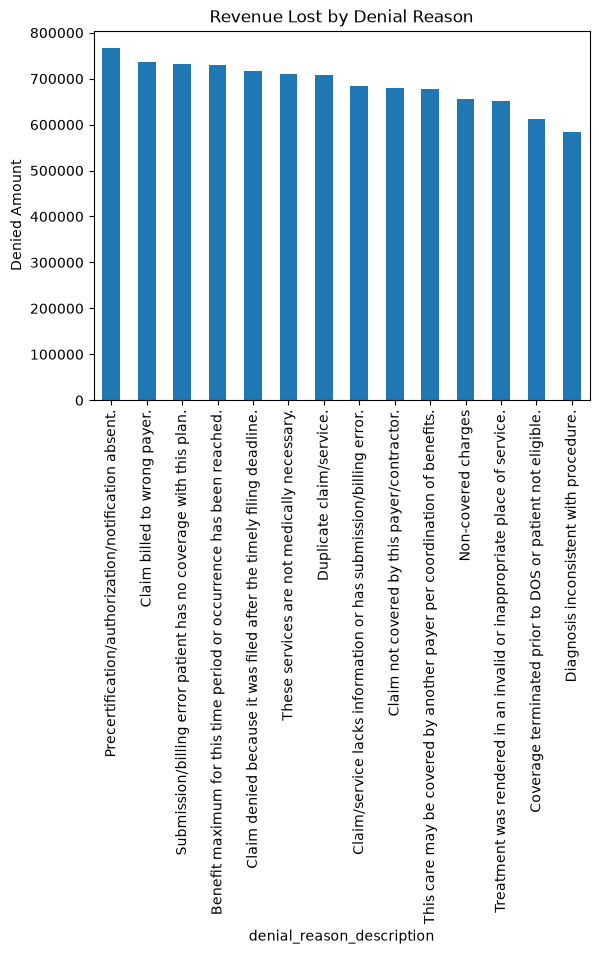

In [23]:
revenue_loss.plot(kind="bar")
plt.title("Revenue Lost by Denial Reason")
plt.ylabel("Denied Amount")
plt.show()

#### Observation

- A few denial reasons contributed to a significant share of revenue leakage.
- These categories should be prioritized during the claims review process.

## Insurance Provider Analysis

In [24]:
insurance_summary = claims.groupby("insurance_provider")[["billed_amount","paid_amount"]].sum()
insurance_summary

,billed_amount,paid_amount
insurance_provider,,
Aetna,15931881.91,10220394.03
BCBS,15937527.71,10319121.06
Cigna,16379391.57,10552126.52
Humana,15957291.04,10324831.81
Medicaid,16297387.90,10458464.11
Medicare,16068518.96,10437368.68
UHC,16328640.75,10533344.33


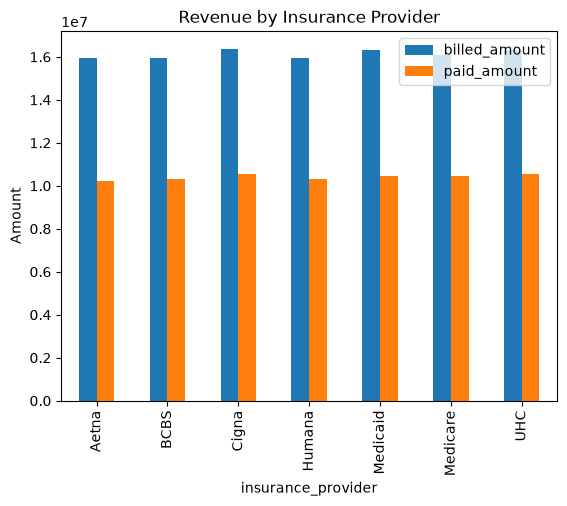

In [25]:
insurance_summary.plot(kind="bar")
plt.title("Revenue by Insurance Provider")
plt.ylabel("Amount")
plt.show()

#### Observation

- Revenue collection varied across insurance providers.
- Some providers contributed more to billed revenue than others.

## Department Analysis

In [26]:
department_visits = encounters["department"].value_counts()
department_visits

department
Emergency Department              16365
Obstetrics & Gynecology            9242
General Surgery                    2545
Radiology / Imaging                2428
Cardiology                         2426
Urology                            2405
Pulmonology                        2404
Gastroenterology                   2392
Internal Medicine                  2372
ENT (Otolaryngology)               2368
Neurology                          2364
Infectious Disease                 2349
Family Medicine                    2348
Pathology / Lab Services           2335
Orthopedics                        2296
Psychiatry / Behavioral Health     2286
Nephrology                         2263
Oncology                           2253
Anesthesiology                     2252
Dermatology                        2237
Pediatrics                         2070
Name: count, dtype: int64

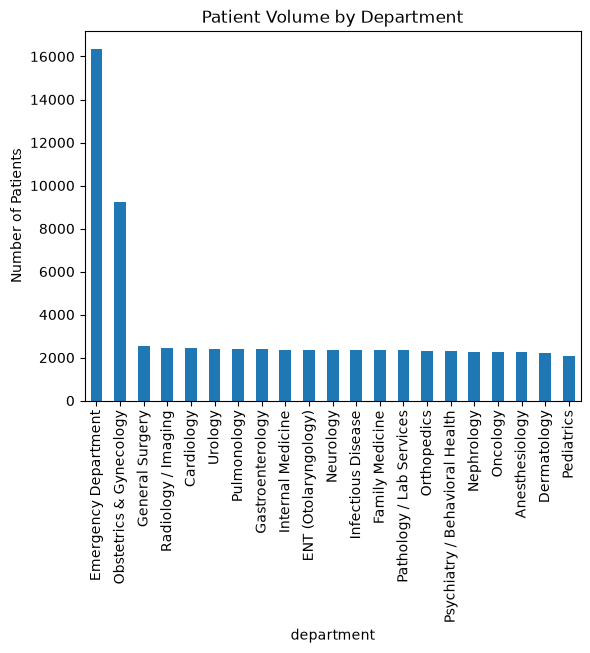

In [27]:
department_visits.plot(kind="bar")
plt.title("Patient Volume by Department")
plt.ylabel("Number of Patients")
plt.show()

####  Observation

- Patient visits were not evenly distributed across departments.
- High-volume departments may require additional operational attention.

## Provider Analysis

In [28]:
provider_workload = encounters["provider_id"].value_counts().head(10)
provider_workload

provider_id
PRO00031    263
PRO00004    263
PRO00007    259
PRO00006    256
PRO00033    255
PRO00011    254
PRO00027    254
PRO00032    251
PRO00009    248
PRO00017    247
Name: count, dtype: int64

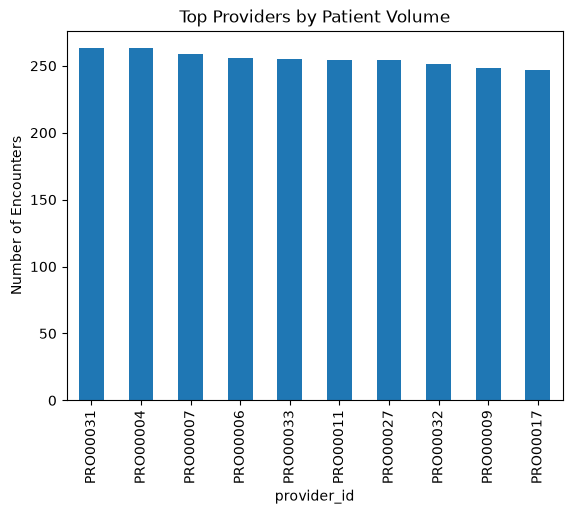

In [29]:
provider_workload.plot(kind="bar")
plt.title("Top Providers by Patient Volume")
plt.ylabel("Number of Encounters")
plt.show()

#### Observation

- A small number of providers handled a larger share of patient encounters.
- Provider workload differed across the hospital.

## Demographic Analysis

In [30]:
patients["gender"].value_counts()

gender
Female    36036
Male      23964
Name: count, dtype: int64

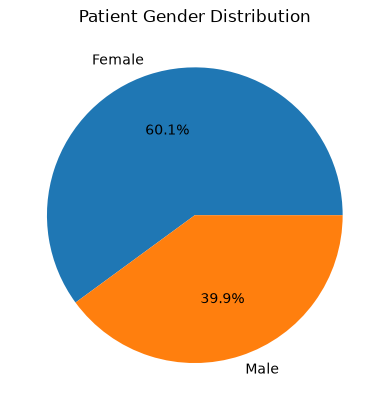

In [31]:
patients["gender"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.ylabel("")
plt.title("Patient Gender Distribution")
plt.show()

#### Observation

- Female patients were slightly more than male patients in the dataset.



## Monthly Revenue Analysis

In [32]:
monthly_revenue = (
    claims.groupby(claims["claim_billing_date"].dt.month)["billed_amount"]
    .sum()
)

monthly_revenue.index = monthly_revenue.index.map({
    1: "January",
    2: "February",
    3: "March",
    4: "April",
    5: "May",
    6: "June",
    7: "July",
    8: "August",
    9: "September",
    10: "October",
    11: "November",
    12: "December"
})

monthly_revenue

claim_billing_date
January      5468105.54
February    28469985.49
March       33781199.32
April       26747450.01
May          1936566.95
Name: billed_amount, dtype: float64

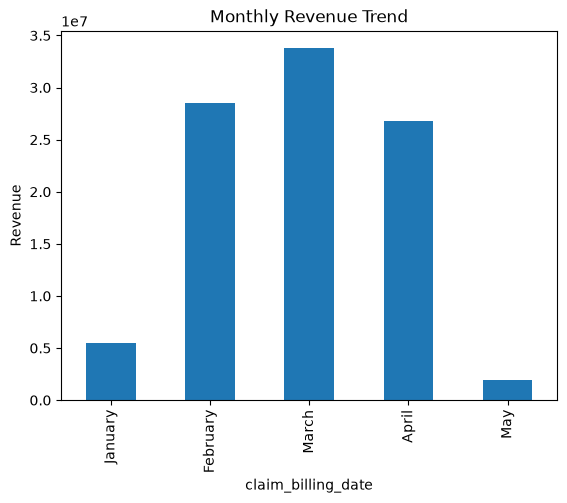

In [33]:
monthly_revenue.plot(kind="bar")
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.show()

#### Observation
- Noticeable changes in revenue were observed between January and February, and between April and May.
  

## Age Distribution

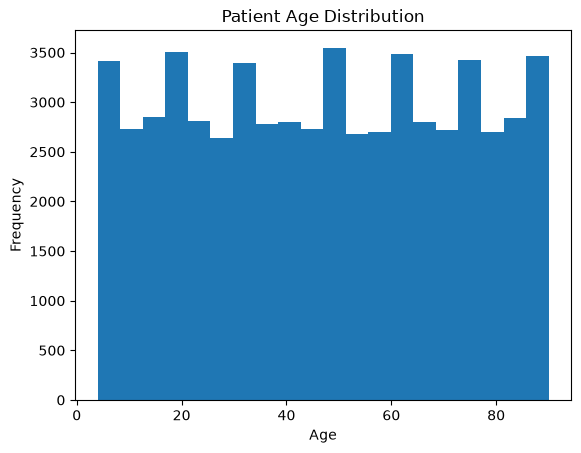

In [34]:
patients["age"].plot(kind="hist", bins=20)
plt.title("Patient Age Distribution")
plt.xlabel("Age")
plt.show()

#### Observation

- Most patients belonged to the adult and middle-aged population.
- The hospital served patients across a wide age range.

## Final Conclusion

This notebook analyzed the healthcare revenue cycle dataset using Python to understand claim performance, revenue trends, and operational metrics.

### Key Findings

- Most insurance claims were successfully approved, while denied claims contributed to revenue leakage.
- Revenue collection varied across different insurance providers.
- Female patients slightly outnumbered male patients in the dataset.
- Monthly revenue showed noticeable fluctuations between January–February and April–May.
- The cleaned dataset is ready for SQL analysis and Power BI dashboard development.

## Export Cleaned Dataset

In [35]:
claims.to_csv("../data/cleaned_claims.csv", index=False)

print("Cleaned dataset exported successfully.")

Cleaned dataset exported successfully.
